# 实验 1：成对排序 (Pairwise Ranking)

In [1]:
import sys
import os
sys.path.append(os.path.abspath('.'))
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import matplotlib.pyplot as plt
from models.ranking import generate_ranking_data
from algorithms.admm import run_u_admm
from utils.excel_utils import append_to_excel
from utils.eval_utils import evaluate_ranking_accuracy, calculate_metrics, evaluate_correlation

# 1. 统一集中定义参数
params = {
    'Experiment': 'Pairwise Ranking',
    'm': 10, 
    'n': 100, # ⚠️ 注意：U-统计量是 O(n^2) 复杂度。n=200 的计算量是 n=100 的 4 倍！调参时建议用 100
    'p_prime': 5, 
    'p': 20, 
    'pc': 0.3,
    'T': 40, 
    'W_inner': 5, 
    'rho': 3.3, 
    'adaptive_rho': False,
    'ic_type': 'bic', # 'aic' 或 'bic'
    'lambda_candidates':  [1, 0.33, 0.1, 0.033, 0.01, 0.0033, 0.001],
    'noise_type': 't1',
    'rng_seed': 95,
    'run_baselines': False  # 设为 False 可以跳过耗时的 Pooled MR 和 D-subGD
}
np.random.seed(params['rng_seed'])

# 2. 生成数据
d_rank = generate_ranking_data(
    m=params['m'], n=params['n'], p_prime=params['p_prime'], 
    p=params['p'], pc=params['pc'], noise_type=params['noise_type'], rng_seed=params['rng_seed']
)
theta_true = d_rank['theta_true']

# 3. 运行 Proposed (U-ADMM)
t0 = time.time()
theta_u_r, theta_n_r, hist_r = run_u_admm(
    d_rank, T=params['T'], W_inner=params['W_inner'], 
    rho=params['rho'], verbose=True,
    adaptive_rho=params.get('adaptive_rho', False),
    lambda_candidates=params.get('lambda_candidates', [0.1, 0.05, 0.01, 0.005, 0.001]),
    ic_type=params.get('ic_type', 'bic')
)
time_uadmm = time.time() - t0
theta_uadmm = theta_u_r[0]
print(f'Proposed 耗时: {time_uadmm:.1f}s')

# 4. 运行其他基线算法
theta_avg = theta_n_r
rmse_local, rmse_global, rmse_dgd = 0.0, 0.0, 0.0
time_global, time_dgd = 0.0, 0.0

if params['run_baselines']:
    from algorithms.admm import init_all_nodes
    theta0_list, _ = init_all_nodes(d_rank)
    local_rmses = [calculate_metrics(theta_true, th)['RMSE'] for th in theta0_list]
    rmse_local = np.mean(local_rmses)
    
    from algorithms.baselines import run_global_u_erm, run_dgd
    t0 = time.time()
    theta_global = run_global_u_erm(d_rank, lambda_candidates=params.get('lambda_candidates'), ic_type=params.get('ic_type', 'bic'))
    time_global = time.time() - t0
    rmse_global = calculate_metrics(theta_true, theta_global)['RMSE']
    print(f'Pooled MR 耗时: {time_global:.1f}s')
    
    t0 = time.time()
    theta_dgd = run_dgd(d_rank, T=params['T'] * params['W_inner'], lr=0.1)
    time_dgd = time.time() - t0
    rmse_dgd = calculate_metrics(theta_true, theta_dgd)['RMSE']
    print(f'D-subGD 耗时: {time_dgd:.1f}s')


  [t=0 init]  RMSE=1.667176
  [t= 1]  RMSE=1.285068, best_lam=1.0000, rho=3.3000, BIC=-0.8161


  [t= 2]  RMSE=1.261888, best_lam=1.0000, rho=3.3000, BIC=-0.9548
  [t= 3]  RMSE=1.312293, best_lam=1.0000, rho=3.3000, BIC=-0.9284


  [t= 4]  RMSE=1.392067, best_lam=1.0000, rho=3.3000, BIC=-0.9084
  [t= 5]  RMSE=1.491419, best_lam=1.0000, rho=3.3000, BIC=-0.8926


  [t= 6]  RMSE=1.579902, best_lam=1.0000, rho=3.3000, BIC=-0.8791
  [t= 7]  RMSE=1.659368, best_lam=1.0000, rho=3.3000, BIC=-0.8545


  [t= 8]  RMSE=1.676648, best_lam=1.0000, rho=3.3000, BIC=-0.8486
  [t= 9]  RMSE=1.727037, best_lam=1.0000, rho=3.3000, BIC=-0.8107


...

  [t=27]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=28]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517


  [t=29]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=30]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517


  [t=31]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=32]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=33]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517


  [t=34]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=35]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=36]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517


  [t=37]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=38]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=39]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
  [t=40]  RMSE=2.000000, best_lam=1.0000, rho=3.3000, BIC=-0.6517
Proposed 耗时: 10.1s


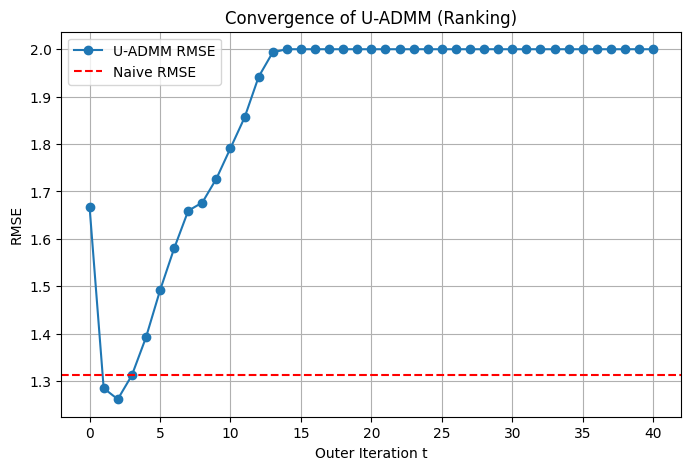

In [2]:
# 绘制收敛曲线
plt.figure(figsize=(8, 5))
plt.plot(hist_r['rmse'], marker='o', label='U-ADMM RMSE')
rmse_naive = np.linalg.norm(theta_n_r - d_rank['theta_true'])
plt.axhline(rmse_naive, color='r', linestyle='--', label='Naive RMSE')
plt.xlabel('Outer Iteration t')
plt.ylabel('RMSE')
plt.title('Convergence of U-ADMM (Ranking)')
plt.legend()
plt.grid(True)
plt.show()


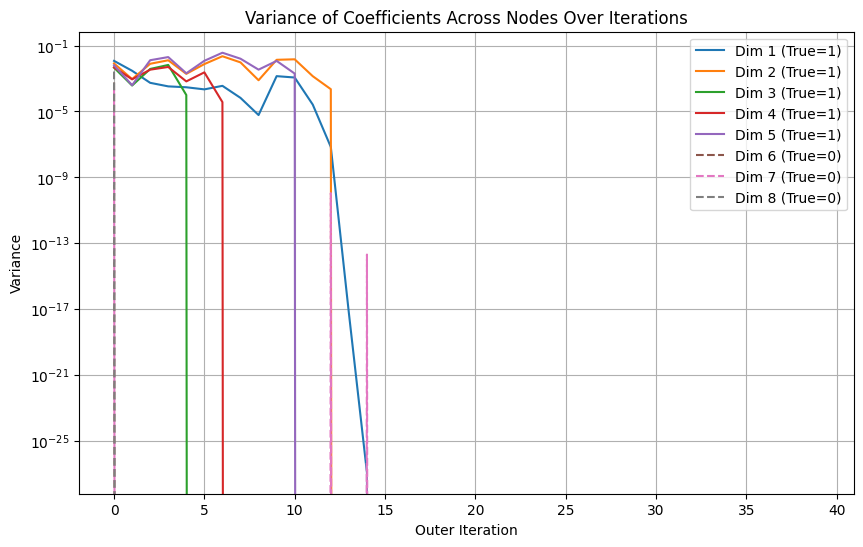

In [3]:
# 绘制系数方差变化图
debug_history = hist_r['debug']
T_iters = len(debug_history)
p = params['p']
variances = np.zeros((T_iters, p))

for t in range(T_iters):
    theta_t = debug_history[t]['theta_t']
    theta_mat = np.hstack(theta_t)
    variances[t, :] = np.var(theta_mat, axis=1)

plt.figure(figsize=(10, 6))
for i in range(params['p_prime']):
    plt.plot(range(T_iters), variances[:, i], label=f'Dim {i+1} (True=1)')
for i in range(params['p_prime'], min(params['p_prime']+3, p)):
    plt.plot(range(T_iters), variances[:, i], linestyle='--', label=f'Dim {i+1} (True=0)')

plt.title('Variance of Coefficients Across Nodes Over Iterations')
plt.xlabel('Outer Iteration')
plt.ylabel('Variance')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


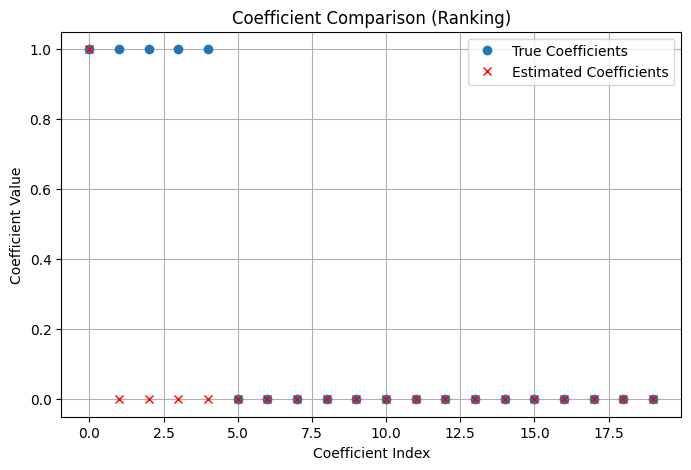

In [4]:
# 绘制系数比较图
plt.figure(figsize=(8, 5))
plt.plot(d_rank['theta_true'], marker='o', linestyle='None', label='True Coefficients')
plt.plot(theta_u_r[0], marker='x', color='r', linestyle='None', label='Estimated Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Comparison (Ranking)')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
# 计算指标并保存到 Excel
metrics_uadmm = calculate_metrics(theta_true, theta_uadmm)
metrics_avg = calculate_metrics(theta_true, theta_avg)
class_metrics = evaluate_ranking_accuracy(d_rank['X'], d_rank['Y'], theta_uadmm, d_rank['quantiles'])
corr_metrics = evaluate_correlation(d_rank['X'], theta_true, theta_uadmm)

print(f"\n=== RMSE 结果 ({params['noise_type']} 噪声) ===")
if params['run_baselines']:
    print(f"1. Pooled MR (Global): {rmse_global:.4f}")
    print(f"2. Local MR:         {rmse_local:.4f}")
print(f"3. Avg MR (Naive):   {metrics_avg['RMSE']:.4f}")
if params['run_baselines']:
    print(f"4. D-subGD:          {rmse_dgd:.4f}")
print(f"5. Proposed (U-ADMM): {metrics_uadmm['RMSE']:.4f}")
print(f"\nPairwise Correlation (Proposed): {class_metrics['Pairwise_Correlation']:.4f}")
print(f"Pearson Correlation (Proposed): {corr_metrics['Pearson_Corr']:.4f}")
print(f"Kendall Correlation (Proposed): {corr_metrics['Kendall_Corr']:.4f}")
print(f"\n变量选择 F1-Score (Proposed): {metrics_uadmm['F1_Score']:.4f}")
print(f"变量选择 Recall (Proposed): {metrics_uadmm['Recall']:.4f}")
print(f"变量选择 Precision (Proposed): {metrics_uadmm['Precision']:.4f}")
print(f"变量选择 Accuracy (Proposed): {metrics_uadmm['Selection_Acc']:.4f}")

record = params.copy()
record['RMSE'] = metrics_uadmm['RMSE']
record['MAE'] = metrics_uadmm['MAE']
record['Selection_Acc'] = metrics_uadmm['Selection_Acc']
record['Precision'] = metrics_uadmm['Precision']
record['Recall'] = metrics_uadmm['Recall']
record['F1_Score'] = metrics_uadmm['F1_Score']
record['Pearson_Corr'] = corr_metrics['Pearson_Corr']
record['Kendall_Corr'] = corr_metrics['Kendall_Corr']
record['Avg_RMSE'] = metrics_avg['RMSE']
if params['run_baselines']:
    record['Pooled_RMSE'] = rmse_global
    record['Local_RMSE'] = rmse_local
    record['DGD_RMSE'] = rmse_dgd

# 记录第一个节点的所有系数估计
for i, coef in enumerate(theta_uadmm.flatten()):
    record[f'theta_{i}'] = coef

record.update(class_metrics)

os.makedirs('exp1', exist_ok=True)
append_to_excel('exp1/experiment_results.xlsx', record)
print('结果已保存到 exp1/experiment_results.xlsx')



=== RMSE 结果 (t1 噪声) ===
3. Avg MR (Naive):   1.3129
5. Proposed (U-ADMM): 2.0000

Pairwise Correlation (Proposed): 0.7471
Pearson Correlation (Proposed): 0.7771
Kendall Correlation (Proposed): 0.5662

变量选择 F1-Score (Proposed): 0.3333
变量选择 Recall (Proposed): 0.2000
变量选择 Precision (Proposed): 1.0000
变量选择 Accuracy (Proposed): 0.8000


结果已保存到 exp1/experiment_results.xlsx
